<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/07_Evaluation_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Home Indoor Scene Recognition from Images
## Notebook 07: Evaluation, Comparison and Final Validation

### Purpose

This notebook provides the final evidence for the HomeVision experiment.

It loads the saved results produced by Notebooks 04–06 and compares:

- test accuracy,
- test loss,
- parameter counts,
- validation behaviour,
- class-wise precision, recall and F1-score,
- confusion matrices,
- learning curves,
- fine-tuning outcomes,
- external-image performance.

The official test set remains the primary final evaluation because it was not used for hyperparameter selection.


## Step 1 — Imports

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Step 2 — Results directory

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
RESULTS_DIR = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results"
CLASSES = ["kitchen", "bedroom", "bar", "livingroom", "warehouse"]

RESULT_FILES = {
    "EfficientNetB0": "efficientnetb0_final_results.json",
    "ConvNeXt-Tiny": "convnext_tiny_final_results.json",
    "ResNet50": "resnet50_final_results.json"
}

for model_name, filename in RESULT_FILES.items():
    path = os.path.join(RESULTS_DIR, filename)
    print(model_name, "exists:", os.path.exists(path), "->", path)

EfficientNetB0 exists: True -> /content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results/efficientnetb0_final_results.json
ConvNeXt-Tiny exists: True -> /content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results/convnext_tiny_final_results.json
ResNet50 exists: True -> /content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results/resnet50_final_results.json


## Step 3 — Load saved results

In [4]:
results = {}

for model_name, filename in RESULT_FILES.items():
    path = os.path.join(RESULTS_DIR, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{filename} was not found. Complete Notebook 04, 05 and 06 first."
        )

    with open(path, "r") as f:
        results[model_name] = json.load(f)

print("Loaded models:", list(results.keys()))

Loaded models: ['EfficientNetB0', 'ConvNeXt-Tiny', 'ResNet50']


## Step 4 — Overall model comparison

In [5]:
comparison_rows = []

for model_name, result in results.items():
    report = result["classification_report"]

    comparison_rows.append({
        "Model": model_name,
        "Test Accuracy": result["test_accuracy"],
        "Test Loss": result["test_loss"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"],
        "Selected Stage": result["selected_stage"],
        "Trainable Parameters": result["trainable_parameters"],
        "Total Parameters": result["total_parameters"]
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Model,Test Accuracy,Test Loss,Macro F1,Weighted F1,Selected Stage,Trainable Parameters,Total Parameters
0,ConvNeXt-Tiny,0.929752,0.203742,0.934483,0.930597,Fine-tuned,14254853,27823973
1,EfficientNetB0,0.904959,0.246628,0.911289,0.905519,Fine-tuned,1460965,4055976
2,ResNet50,0.904959,0.285786,0.910564,0.905666,Frozen backbone,10245,23597957


## Step 5 — Test accuracy comparison

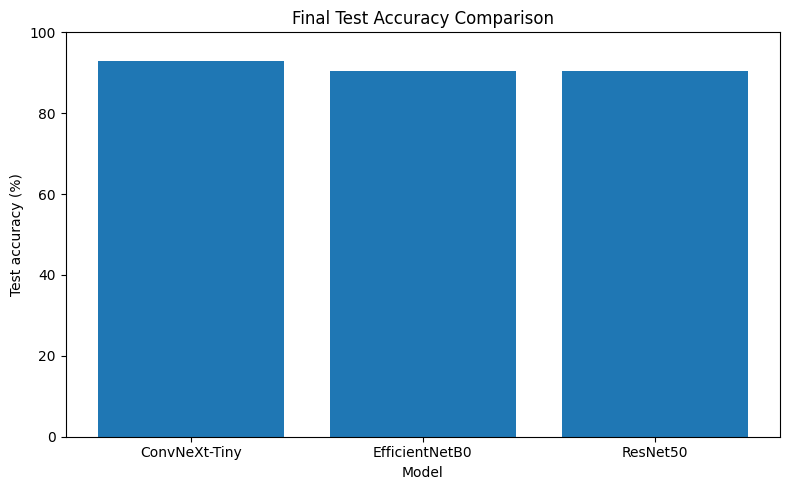

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"] * 100)
plt.ylabel("Test accuracy (%)")
plt.xlabel("Model")
plt.title("Final Test Accuracy Comparison")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Step 6 — Test loss comparison

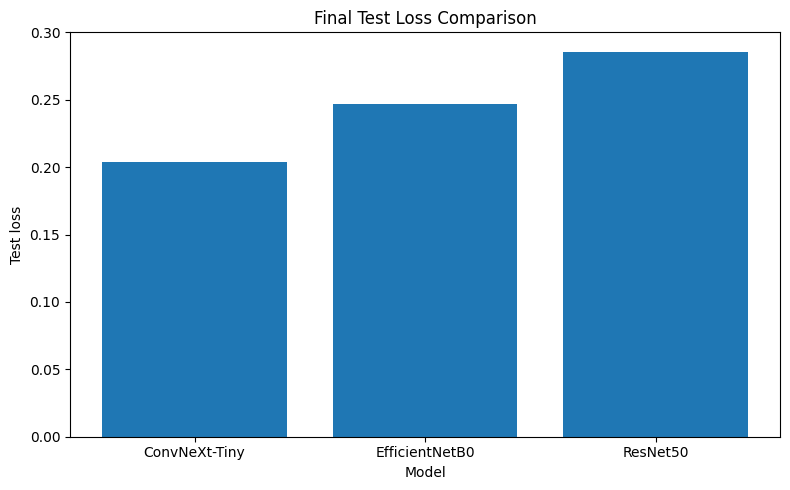

In [7]:
loss_df = comparison_df.sort_values("Test Loss", ascending=True)

plt.figure(figsize=(8, 5))
plt.bar(loss_df["Model"], loss_df["Test Loss"])
plt.ylabel("Test loss")
plt.xlabel("Model")
plt.title("Final Test Loss Comparison")
plt.tight_layout()
plt.show()

## Step 7 — Hyperparameter tuning evidence

In [8]:
tuning_path = os.path.join(RESULTS_DIR, "hyperparameter_tuning.json")

if not os.path.exists(tuning_path):
    raise FileNotFoundError("hyperparameter_tuning.json was not found.")

with open(tuning_path, "r") as f:
    tuning_data = json.load(f)

tuning_df = pd.DataFrame(tuning_data["results"])

display(tuning_df[[
    "config_id",
    "learning_rate",
    "dropout",
    "mean_val_accuracy",
    "std_val_accuracy",
    "mean_val_loss"
]])

print("Selected learning rate:", tuning_data["selected_learning_rate"])
print("Selected dropout:", tuning_data["selected_dropout"])
print("CV type:", tuning_data["cv_type"])
print("CV folds:", tuning_data["cv_folds"])

,config_id,learning_rate,dropout,mean_val_accuracy,std_val_accuracy,mean_val_loss
0,1,0.0010,0.2,0.848615,0.030725,0.627821
1,2,0.0010,0.4,0.817417,0.010722,0.662739
2,3,0.0001,0.2,0.313509,0.079202,1.512284
3,4,0.0001,0.4,0.288263,0.077277,1.581963


Selected learning rate: 0.001
Selected dropout: 0.2
CV type: StratifiedKFold
CV folds: 3


### Interpretation

Notebook 04 used stratified cross-validation to compare multiple learning-rate and dropout configurations.

The selected configuration is based on validation performance rather than the official test set. This provides experimental evidence for the training settings used by all three final models.


## Step 8 — Fine-tuning comparison

In [9]:
fine_tune_rows = []

for model_name, result in results.items():
    fine_tune_rows.append({
        "Model": model_name,
        "Stage 1 Val Loss": result["stage1_best_val_loss"],
        "Stage 2 Val Loss": result["stage2_best_val_loss"],
        "Stage 1 Val Accuracy": result["stage1_best_val_accuracy"],
        "Stage 2 Val Accuracy": result["stage2_best_val_accuracy"],
        "Selected Stage": result["selected_stage"],
        "Fine-tuned Layers": result["fine_tune_layers"],
        "Fine-tune LR": result["fine_tune_learning_rate"]
    })

fine_tune_df = pd.DataFrame(fine_tune_rows)

display(fine_tune_df)

,Model,Stage 1 Val Loss,Stage 2 Val Loss,Stage 1 Val Accuracy,Stage 2 Val Accuracy,Selected Stage,Fine-tuned Layers,Fine-tune LR
0,EfficientNetB0,0.259961,0.257001,0.912863,0.908714,Fine-tuned,20,0.00001
1,ConvNeXt-Tiny,0.219658,0.204588,0.919087,0.925311,Fine-tuned,20,0.00001
2,ResNet50,0.288215,0.300433,0.885892,0.906639,Frozen backbone,20,0.00001


## Step 9 — Class-wise metrics comparison

In [10]:
metric_rows = []

for model_name, result in results.items():
    report = result["classification_report"]

    for class_name in CLASSES:
        metric_rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1-score": report[class_name]["f1-score"],
            "Support": int(report[class_name]["support"])
        })

class_metrics_df = pd.DataFrame(metric_rows)
display(class_metrics_df)

,Model,Class,Precision,Recall,F1-score,Support
0,EfficientNetB0,kitchen,0.954545,0.945946,0.950226,111
1,EfficientNetB0,bedroom,0.833333,0.850000,0.841584,100
2,EfficientNetB0,bar,0.977273,0.945055,0.960894,91
3,EfficientNetB0,livingroom,0.796296,0.811321,0.803738,106
4,EfficientNetB0,warehouse,1.000000,1.000000,1.000000,76
5,ConvNeXt-Tiny,kitchen,0.990385,0.927928,0.958140,111
6,ConvNeXt-Tiny,bedroom,0.887755,0.870000,0.878788,100
7,ConvNeXt-Tiny,bar,0.988636,0.956044,0.972067,91
8,ConvNeXt-Tiny,livingroom,0.829060,0.915094,0.869955,106
9,ConvNeXt-Tiny,warehouse,0.987013,1.000000,0.993464,76


## Step 10 — Class-wise F1 comparison

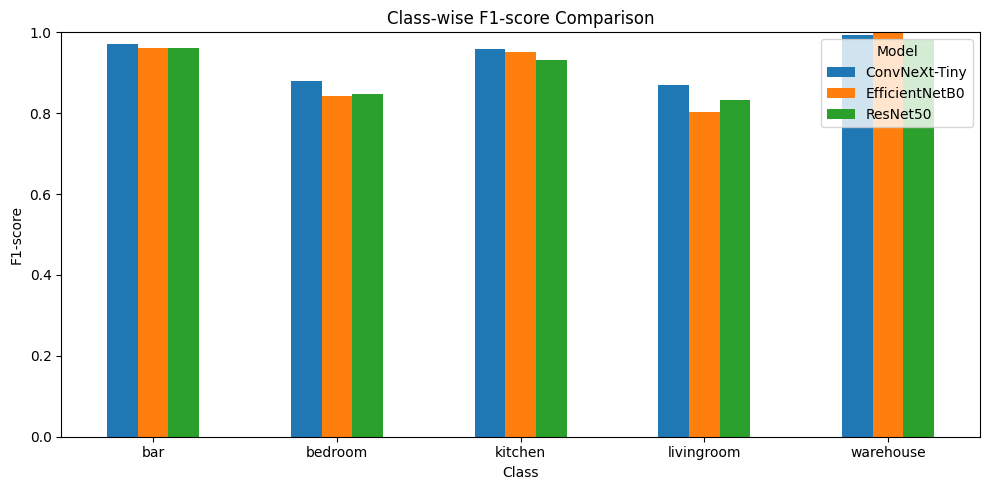

In [11]:
f1_table = class_metrics_df.pivot(
    index="Class",
    columns="Model",
    values="F1-score"
)

f1_table.plot(
    kind="bar",
    figsize=(10, 5)
)
plt.ylabel("F1-score")
plt.xlabel("Class")
plt.title("Class-wise F1-score Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 11 — Confusion matrices

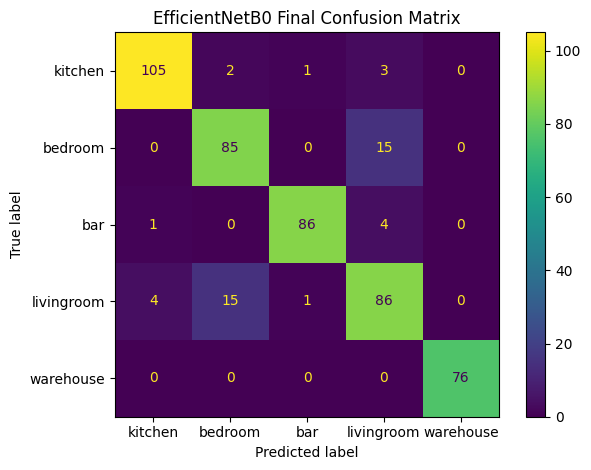

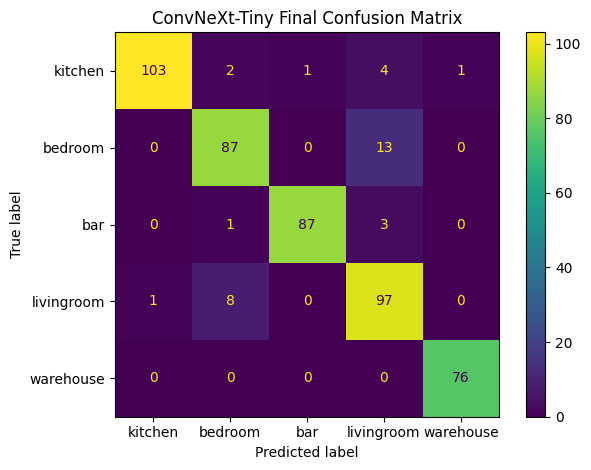

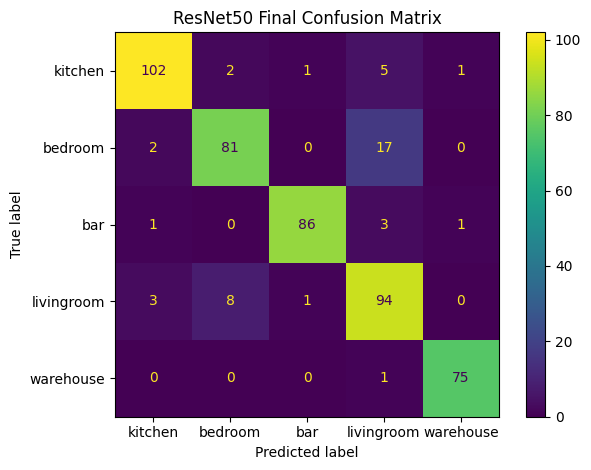

In [12]:
for model_name, result in results.items():
    cm = np.array(result["confusion_matrix"])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASSES
    )
    disp.plot()
    plt.title(f"{model_name} Final Confusion Matrix")
    plt.tight_layout()
    plt.show()

## Step 12 — Learning curves for all models

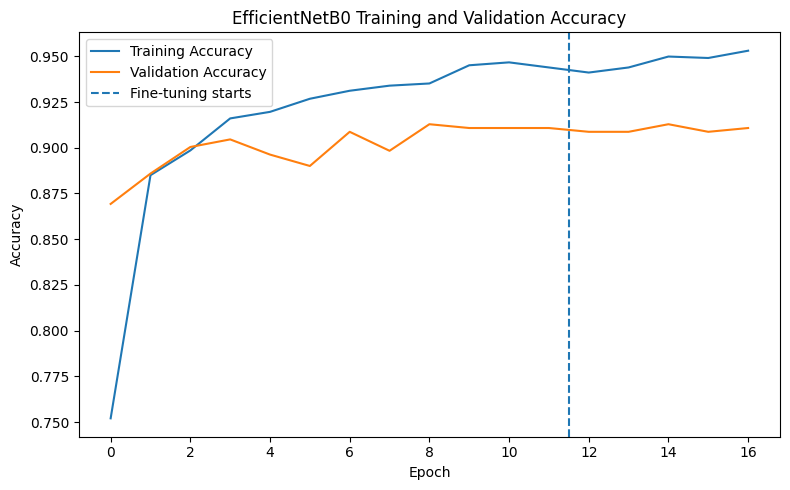

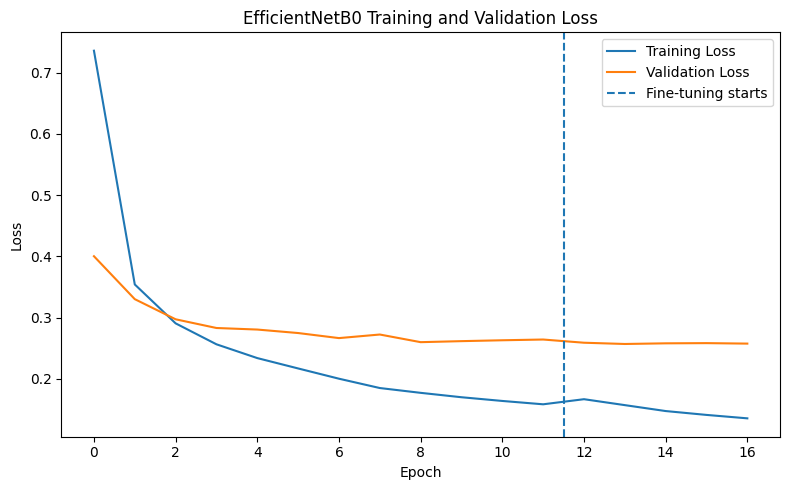

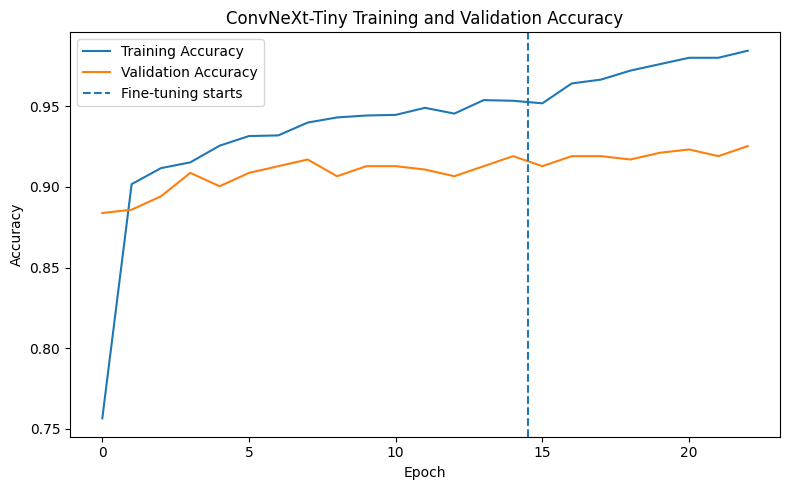

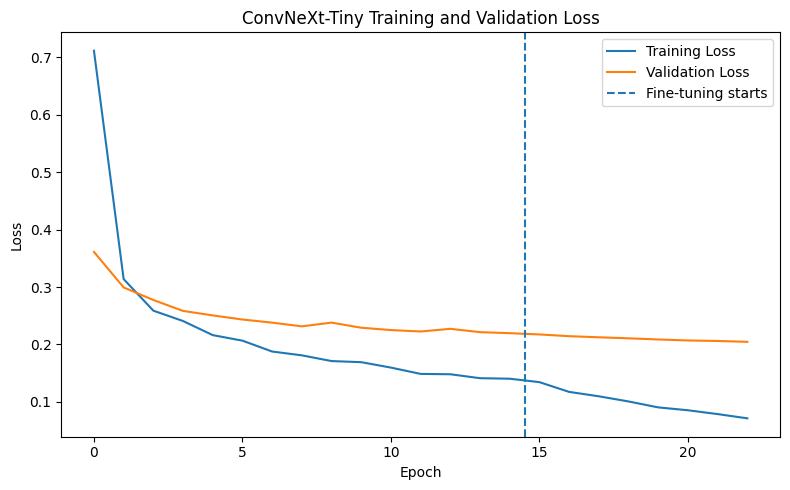

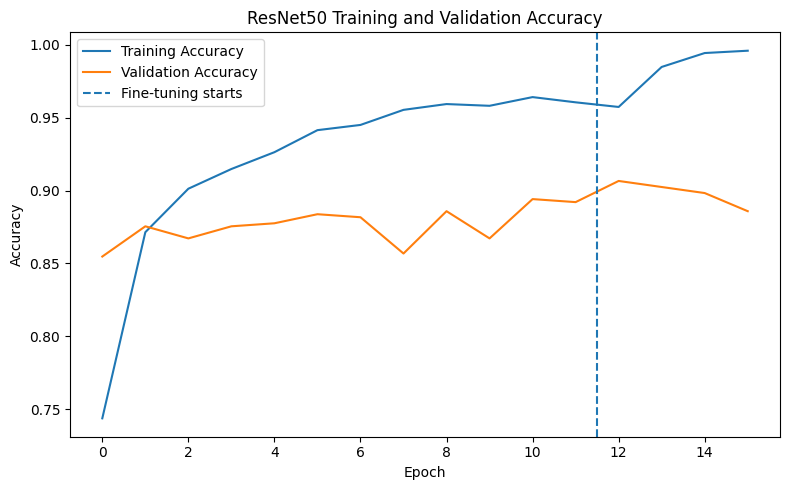

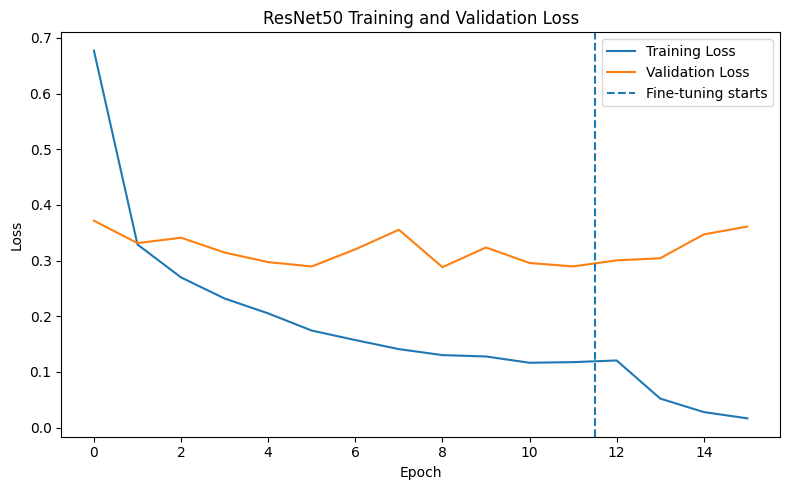

In [13]:
for model_name, result in results.items():
    history = result["history"]

    plt.figure(figsize=(8, 5))
    plt.plot(history["accuracy"], label="Training Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    stage1_epochs = result["epochs_stage1"]

    if stage1_epochs < len(history["accuracy"]):
        plt.axvline(
            stage1_epochs - 0.5,
            linestyle="--",
            label="Fine-tuning starts"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Training and Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    if stage1_epochs < len(history["loss"]):
        plt.axvline(
            stage1_epochs - 0.5,
            linestyle="--",
            label="Fine-tuning starts"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Step 13 — Training behaviour and overfitting check

In [14]:
behaviour_rows = []

for model_name, result in results.items():
    history = result["history"]

    best_val_loss_index = int(np.argmin(history["val_loss"]))
    last_val_loss = float(history["val_loss"][-1])
    best_val_loss = float(history["val_loss"][best_val_loss_index])

    final_train_accuracy = float(history["accuracy"][-1])
    final_val_accuracy = float(history["val_accuracy"][-1])

    behaviour_rows.append({
        "Model": model_name,
        "Best Validation Loss": best_val_loss,
        "Best Validation Loss Epoch": best_val_loss_index + 1,
        "Last Validation Loss": last_val_loss,
        "Final Train Accuracy": final_train_accuracy,
        "Final Validation Accuracy": final_val_accuracy,
        "Train-Val Accuracy Gap": final_train_accuracy - final_val_accuracy,
        "Validation Loss Increased After Best": last_val_loss > best_val_loss
    })

behaviour_df = pd.DataFrame(behaviour_rows)
display(behaviour_df)

,Model,Best Validation Loss,Best Validation Loss Epoch,Last Validation Loss,Final Train Accuracy,Final Validation Accuracy,Train-Val Accuracy Gap,Validation Loss Increased After Best
0,EfficientNetB0,0.257001,14,0.257606,0.953044,0.910788,0.042256,True
1,ConvNeXt-Tiny,0.204588,23,0.204588,0.984481,0.925311,0.059169,False
2,ResNet50,0.288215,9,0.361125,0.996021,0.885892,0.110129,True


### Interpretation rule

A rise in validation loss after the best validation point is evidence that the model started losing validation performance later in training.

The accuracy gap should also be considered. These indicators are used to discuss generalisation rather than claiming that a model is overfitting from accuracy alone.


## Step 14 — Parameter and efficiency comparison

In [15]:
parameter_df = comparison_df[[
    "Model",
    "Total Parameters",
    "Trainable Parameters",
    "Selected Stage"
]].copy()

display(parameter_df)

print("\nEfficiency note:")
print("Parameter count is reported as a model-size indicator.")
print("Actual device latency was not measured in this experiment, so no latency claim is made.")

,Model,Total Parameters,Trainable Parameters,Selected Stage
0,ConvNeXt-Tiny,27823973,14254853,Fine-tuned
1,EfficientNetB0,4055976,1460965,Fine-tuned
2,ResNet50,23597957,10245,Frozen backbone



Efficiency note:
Parameter count is reported as a model-size indicator.
Actual device latency was not measured in this experiment, so no latency claim is made.


## Step 15 — Identify the hardest and easiest classes

In [16]:
average_f1_by_class = (
    class_metrics_df
    .groupby("Class")["F1-score"]
    .mean()
    .sort_values()
)

print("Average F1-score by class:")
display(average_f1_by_class.to_frame("Average F1-score"))

print(
    f"Hardest class by average F1-score: "
    f"{average_f1_by_class.index[0]} "
    f"({average_f1_by_class.iloc[0]:.4f})"
)

print(
    f"Easiest class by average F1-score: "
    f"{average_f1_by_class.index[-1]} "
    f"({average_f1_by_class.iloc[-1]:.4f})"
)

Average F1-score by class:


,Average F1-score
Class,
livingroom,0.835184
bedroom,0.856180
kitchen,0.946624
bar,0.964618
warehouse,0.991285


Hardest class by average F1-score: livingroom (0.8352)
Easiest class by average F1-score: warehouse (0.9913)


## Step 16 — Confusion pair analysis

In [17]:
for model_name, result in results.items():
    cm = np.array(result["confusion_matrix"], dtype=int)

    off_diagonal = []
    for true_idx in range(NUM_CLASSES if "NUM_CLASSES" in globals() else len(CLASSES)):
        for pred_idx in range(len(CLASSES)):
            if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
                off_diagonal.append({
                    "True Class": CLASSES[true_idx],
                    "Predicted Class": CLASSES[pred_idx],
                    "Count": cm[true_idx, pred_idx]
                })

    off_diagonal_df = pd.DataFrame(off_diagonal).sort_values(
        "Count", ascending=False
    )

    print(f"\n{model_name} most common confusion pairs:")
    display(off_diagonal_df.head(10))


EfficientNetB0 most common confusion pairs:


,True Class,Predicted Class,Count
3,bedroom,livingroom,15
7,livingroom,bedroom,15
5,bar,livingroom,4
6,livingroom,kitchen,4
2,kitchen,livingroom,3
0,kitchen,bedroom,2
1,kitchen,bar,1
4,bar,kitchen,1
8,livingroom,bar,1



ConvNeXt-Tiny most common confusion pairs:


,True Class,Predicted Class,Count
4,bedroom,livingroom,13
8,livingroom,bedroom,8
2,kitchen,livingroom,4
6,bar,livingroom,3
0,kitchen,bedroom,2
3,kitchen,warehouse,1
1,kitchen,bar,1
5,bar,bedroom,1
7,livingroom,kitchen,1



ResNet50 most common confusion pairs:


,True Class,Predicted Class,Count
5,bedroom,livingroom,17
10,livingroom,bedroom,8
2,kitchen,livingroom,5
7,bar,livingroom,3
9,livingroom,kitchen,3
4,bedroom,kitchen,2
0,kitchen,bedroom,2
3,kitchen,warehouse,1
1,kitchen,bar,1
8,bar,warehouse,1


## Step 17 — External image comparison

In [18]:
ACTUAL_CLASSES = {
    "81.jpg": "kitchen",
    "06.jpg": "kitchen",
    "32.jpg": "kitchen",
    "97.jpg": "kitchen",
    "92.jpg": "bedroom",
    "88.jpg": "bedroom",
    "68.jpg": "bedroom",
    "22.jpg": "bar",
    "71.jpg": "bar",
    "07.jpg": "bar",
    "33.jpg": "bar",
    "29.jpg": "bar",
    "73.jpg": "bar",
    "18.jpg": "livingroom",
    "75.jpg": "livingroom",
    "58.jpg": "livingroom",
    "13.jpg": "livingroom",
    "37.jpg": "warehouse",
    "16.jpg": "warehouse",
    "91.jpg": "warehouse"
}

external_data = {}

for model_name, filename in {
    "EfficientNetB0": "efficientnet_external_predictions.json",
    "ConvNeXt-Tiny": "convnext_external_predictions.json",
    "ResNet50": "resnet50_external_predictions.json"
}.items():

    path = os.path.join(RESULTS_DIR, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{filename} not found. Run the external prediction step in {model_name} notebook."
        )

    with open(path, "r") as f:
        external_data[model_name] = json.load(f)

image_order = external_data["EfficientNetB0"]["image_order"]

for model_name in external_data:
    if external_data[model_name]["image_order"] != image_order:
        raise ValueError(f"Image order does not match for {model_name}")

external_rows = []

for index, image_name in enumerate(image_order):
    row = {
        "Image": image_name,
        "Actual Class": ACTUAL_CLASSES[image_name]
    }

    for model_name in external_data:
        pred = external_data[model_name]["predictions"][index]
        row[f"{model_name} Prediction"] = pred["predicted_class"]
        row[f"{model_name} Confidence"] = pred["confidence"]

    row["All Models Agree"] = len({
        row["EfficientNetB0 Prediction"],
        row["ConvNeXt-Tiny Prediction"],
        row["ResNet50 Prediction"]
    }) == 1

    external_rows.append(row)

external_df = pd.DataFrame(external_rows)

display(external_df)

,Image,Actual Class,EfficientNetB0 Prediction,EfficientNetB0 Confidence,ConvNeXt-Tiny Prediction,ConvNeXt-Tiny Confidence,ResNet50 Prediction,ResNet50 Confidence,All Models Agree
0,81.jpg,kitchen,kitchen,0.998068,kitchen,0.985384,kitchen,0.997890,True
1,06.jpg,kitchen,kitchen,0.996769,kitchen,0.993405,livingroom,0.490650,False
2,32.jpg,kitchen,kitchen,0.997253,kitchen,0.999949,kitchen,0.999570,True
3,97.jpg,kitchen,livingroom,0.543359,kitchen,0.972407,livingroom,0.576771,False
4,92.jpg,bedroom,livingroom,0.652443,bedroom,0.929553,livingroom,0.781359,False
5,88.jpg,bedroom,bedroom,0.995801,bedroom,0.998825,bedroom,0.919312,True
6,68.jpg,bedroom,livingroom,0.848942,livingroom,0.821765,livingroom,0.671373,True
7,22.jpg,bar,bar,0.999614,bar,0.988752,bar,0.999971,True
8,71.jpg,bar,bar,0.999938,bar,0.999846,bar,0.942805,True
9,07.jpg,bar,bar,0.877435,bar,0.999670,bar,0.998864,True


## Step 18 — External accuracy calculation

In [19]:
external_accuracy = {}

for model_name in external_data:
    predictions = external_df[f"{model_name} Prediction"].tolist()
    actual = external_df["Actual Class"].tolist()

    accuracy = np.mean(
        [pred == true for pred, true in zip(predictions, actual)]
    )

    external_accuracy[model_name] = float(accuracy)

agreement_count = int(external_df["All Models Agree"].sum())
disagreement_count = len(external_df) - agreement_count

external_summary_df = pd.DataFrame({
    "Model": list(external_accuracy.keys()),
    "External Accuracy": list(external_accuracy.values())
})

display(external_summary_df)

print("All models agree on:", agreement_count, "of", len(external_df))
print("Models disagree on:", disagreement_count, "of", len(external_df))

,Model,External Accuracy
0,EfficientNetB0,0.75
1,ConvNeXt-Tiny,0.90
2,ResNet50,0.75


All models agree on: 15 of 20
Models disagree on: 5 of 20


### External evaluation interpretation

The external set contains only 20 images, so it is treated as an additional generalisation check rather than the primary performance measure.

The official held-out test-set results remain the main basis for model comparison.

Confidence should also be interpreted carefully: a high-confidence prediction can still be incorrect.


## Step 19 — Final factual comparison

In [20]:
highest_accuracy_row = comparison_df.iloc[0]
lowest_loss_row = comparison_df.sort_values("Test Loss").iloc[0]

print("============================")
print("FINAL FACTUAL COMPARISON")
print("============================")
print(
    f"Highest final test accuracy: "
    f"{highest_accuracy_row['Model']} "
    f"({highest_accuracy_row['Test Accuracy']:.2%})"
)
print(
    f"Lowest final test loss: "
    f"{lowest_loss_row['Model']} "
    f"({lowest_loss_row['Test Loss']:.4f})"
)
print(
    f"Hardest class by average F1: "
    f"{average_f1_by_class.index[0]} "
    f"({average_f1_by_class.iloc[0]:.4f})"
)
print(
    f"Easiest class by average F1: "
    f"{average_f1_by_class.index[-1]} "
    f"({average_f1_by_class.iloc[-1]:.4f})"
)

for model_name, accuracy in external_accuracy.items():
    print(f"{model_name} external accuracy: {accuracy:.2%}")

print(
    f"All models agreed on {agreement_count}/{len(external_df)} "
    f"external images ({agreement_count / len(external_df):.2%})."
)

FINAL FACTUAL COMPARISON
Highest final test accuracy: ConvNeXt-Tiny (92.98%)
Lowest final test loss: ConvNeXt-Tiny (0.2037)
Hardest class by average F1: livingroom (0.8352)
Easiest class by average F1: warehouse (0.9913)
EfficientNetB0 external accuracy: 75.00%
ConvNeXt-Tiny external accuracy: 90.00%
ResNet50 external accuracy: 75.00%
All models agreed on 15/20 external images (75.00%).


## Step 20 — Save final comparison

In [22]:
comparison_output_path = os.path.join(
    RESULTS_DIR,
    "final_model_comparison.json"
)

final_comparison = {
    "model_comparison": comparison_df.to_dict(orient="records"),
    "class_metrics": class_metrics_df.to_dict(orient="records"),
    "fine_tuning_comparison": fine_tune_df.to_dict(orient="records"),
    "training_behaviour": behaviour_df.to_dict(orient="records"),
    "external_accuracy": external_accuracy,
    "external_agreement_count": agreement_count,
    "external_disagreement_count": disagreement_count
}

with open(comparison_output_path, "w") as f:
    json.dump(final_comparison, f, indent=2)

print("Final comparison saved to:", comparison_output_path)

Final comparison saved to: /content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results/final_model_comparison.json


## Step 22 — Final conclusions

The final conclusions must be based on the values printed above after the notebooks have been rerun.

The experiment now contains:

- data preparation and augmentation,
- systematic hyperparameter experimentation,
- stratified cross-validation,
- transfer learning,
- selective fine-tuning,
- validation-based model selection,
- final held-out test evaluation,
- class-wise analysis,
- confusion matrices,
- learning curves,
- external-image evaluation.

Do not enter numerical results manually in this notebook. The comparison is loaded from the saved model-result files so that the written interpretation remains consistent with the actual experiment.
